# FINMARK CUSTOMERS, PRODUCTS, AND TRANSACTIONS EXPLORATORY DATA ANALYSIS

1. Data Loading: We began by importing multiple datasets related to customer transactions, satisfaction scores, and engagement. This step allowed us to access the necessary data for analysis.

2. Preview of Data: The .head() function was used to display the first few rows of each dataset. This provided insight into column names, data types, and general structure.

3. Missing Values Analysis: A missing value check was performed to determine if any columns had incomplete data. Identifying missing values was critical for deciding whether to impute or remove them.

4. Duplicate Detection and Removal: We checked for duplicate rows within the dataset. Any duplicate records found were removed to maintain data accuracy and prevent bias in analysis.

5. Data Skewness Check (Shapiro-Wilk Test): Skewness was examined in numerical variables, particularly transaction amounts and customer satisfaction scores. This helped assess whether the data followed a normal distribution.

6. Outlier Detection (Interquartile Range - IQR Method): The IQR method was applied to detect extreme values in customer-related data. Outliers can significantly impact machine learning models and summary statistics, so identifying them was essential.

7. Handling Missing Values: For columns with missing data, appropriate imputation techniques (such as mean, median, or mode) were applied. Since missing values were below 5%, imputing was preferred over dropping data.

8. Data Type Conversion: Some columns were converted to appropriate data types to facilitate analysis. For instance, dates stored as strings were transformed into datetime objects.

9. Descriptive Statistics: Summary statistics were generated to understand the central tendency and dispersion of numerical data. This included mean, median, standard deviation, and percentiles.

10. Data Visualization: Various visualizations were used to explore relationships between variables:

- Histograms: Showed the distribution of numerical data.
- Countplots: Displayed categorical variable distributions.
- Boxplots: Helped identify outliers.
- Scatterplots & Regression Plots: Examined correlations between satisfaction scores and recommendations.
  
11. Data Normalization (Standard Scaler): To ensure all numerical data were on the same scale, we applied StandardScaler to customer and transaction data. This step was essential for improving clustering accuracy.

12. K-Means Clustering: K-Means clustering was applied to segment customers based on their transaction amount and satisfaction scores. The optimal number of clusters was determined using the elbow method, and results were visualized to interpret customer segments.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
import scipy.cluster.hierarchy as sch
from scipy.cluster.hierarchy import dendrogram, linkage

## 1. LOADING ALL THE DATASETS
In this step, we import the necessary datasets into our environment using Pandas. This allows us to analyze and manipulate the data for further processing.

In [2]:
# Load datasets
transaction_file = "Transaction_Data.csv"
product_file = "Product_Offering_Data (1).csv"
customer_file = "Customer_Feedback_Data.csv"

transactions = pd.read_csv(transaction_file)
products = pd.read_csv(product_file)
customers = pd.read_csv(customer_file)

## 2. SHOWING THE HEADING OF EACH DATASET
- Display First Few Rows of Each Dataset
- We use .head() to preview the first few rows of each dataset.
- This helps us understand the structure, column names, and data types.

In [3]:
# Show headings of transactions
print(transactions.head())

   Transaction_ID  Customer_ID     Transaction_Date  Transaction_Amount  \
0               1          393  2023-01-01 00:00:00              3472.0   
1               2          826  2023-01-01 01:00:00                 NaN   
2               3          916  2023-01-01 02:00:00                10.0   
3               4          109  2023-01-01 03:00:00                72.0   
4               5          889  2023-01-01 04:00:00              1793.0   

  Transaction_Type  
0         Purchase  
1     Bill Payment  
2         Purchase  
3       Investment  
4       Investment  


In [4]:
# Show headings of products
print(products.head())

   Product_ID                   Product_Name     Product_Type Risk_Level  \
0           1           Platinum Credit Card      Credit Card     Medium   
1           2           Gold Savings Account  Savings Account        Low   
2           3  High-Yield Investment Account       Investment       High   
3           4                  Mortgage Loan             Loan     Medium   
4           5                      Auto Loan             Loan     Medium   

   Target_Age_Group Target_Income_Group  
0               NaN              Medium  
1               NaN                 Low  
2               NaN                High  
3               NaN                High  
4               NaN              Medium  


In [5]:
# Show headings of customers
print(customers.head())

   Customer_ID  Satisfaction_Score  Feedback_Comments  Likelihood_to_Recommend
0            1                10.0     Very satisfied                        9
1            2                 3.0     Very satisfied                        3
2            3                10.0     Very satisfied                        1
3            4                 7.0  Needs improvement                        4
4            5                 8.0     Unsatisfactory                        7


## 3. CHECKING FOR MISSING VALUES
- Checking for Missing Values
- We use .isnull().sum() to count the number of missing values in each column.
- This helps identify columns that require data imputation or removal.

In [6]:
# Check for missing values
print(transactions.isnull().sum())
print(products.isnull().sum())
print(customers.isnull().sum())

Transaction_ID          0
Customer_ID             0
Transaction_Date        0
Transaction_Amount    100
Transaction_Type        0
dtype: int64
Product_ID              0
Product_Name            0
Product_Type            0
Risk_Level              0
Target_Age_Group       15
Target_Income_Group     0
dtype: int64
Customer_ID                  0
Satisfaction_Score         101
Feedback_Comments            0
Likelihood_to_Recommend      0
dtype: int64


## 4. CHECKING FOR DUPLICATES
- We use .duplicated().sum() to count duplicate rows in the dataset.
- Identifying duplicate records is crucial to maintain data integrity.

In [7]:
# Check for duplicates in transactions
print(transactions.duplicated().sum())
print(products.duplicated().sum())
print(customers.duplicated().sum())

50
5
81


## 5. DROPPING THE DUPLCATES
- Removing Duplicate Entries
- We use .drop_duplicates() on all datasets to ensure data uniqueness.
- This step helps eliminate redundant records and prevents incorrect analysis.

In [8]:
# Drop duplicates from all datasets
transactions.drop_duplicates(inplace=True)
products.drop_duplicates(inplace=True)
customers.drop_duplicates(inplace=True)

## 6. CHECKING FOR SKEWNESS (SHAPIRO-WILK TEST)
- Checking Data Skewness (Shapiro-Wilk Test)
- Skewness measures the asymmetry of data distribution.
- We perform the Shapiro-Wilk test on numerical columns, such as transaction amounts, to determine normality.
- If skewness is high, we may need to apply transformations or impute missing values.

In [9]:
# Check for skewness using Shapiro-Wilk test
shapiro_test_trans = shapiro(transactions['Transaction_Amount'].dropna())
shapiro_test_cust = shapiro(customers['Satisfaction_Score'].dropna())
print(f"Shapiro-Wilk test for Transaction Amount: {shapiro_test_trans}")
print(f"Shapiro-Wilk test for Satisfaction Score: {shapiro_test_cust}")

Shapiro-Wilk test for Transaction Amount: ShapiroResult(statistic=0.05235368553861175, pvalue=4.807730692666409e-94)
Shapiro-Wilk test for Satisfaction Score: ShapiroResult(statistic=0.7079545690044813, pvalue=2.2627974536637874e-68)


Shapiro-Wilk Test: Statistic=0.9414785964162959, p-value=1.5982944405936784e-40
The distribution is not normal.

Descriptive Statistics for 'Satisfaction_Score':
count    4.969000e+03
mean    -1.286956e-17
std      1.000101e+00
min     -1.646974e+00
25%     -9.340361e-01
50%      1.353707e-01
75%      8.483085e-01
max      1.561246e+00
Name: Satisfaction_Score, dtype: float64

Mode of 'Satisfaction_Score': 0.4918395844455161

Number of missing values after replacing with mode: 0


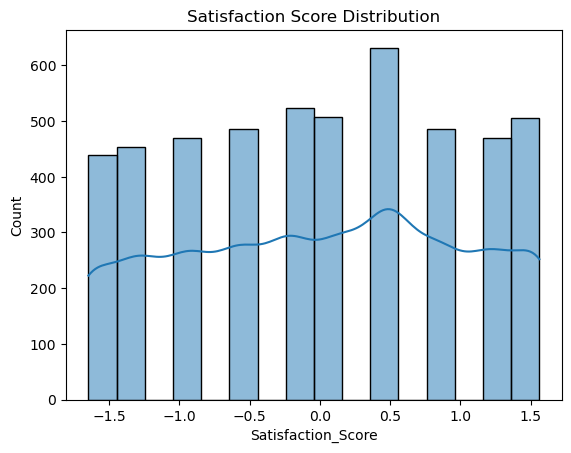

In [ ]:
# Check for normality using Shapiro-Wilk test (for Satisfaction_Score column)
stat, p_value = shapiro(customers['Satisfaction_Score'].dropna())  # Drop NaN for the test
print(f"Shapiro-Wilk Test: Statistic={stat}, p-value={p_value}")

# If p-value is less than 0.05, the distribution is not normal
if p_value < 0.05:
    print("The distribution is not normal.")
    
    # Calculate descriptive statistics
    description = customers['Satisfaction_Score'].describe()
    print("\nDescriptive Statistics for 'Satisfaction_Score':")
    print(description)
    
    # Calculate mode value
    mode_value = customers['Satisfaction_Score'].mode()[0]  # Mode is the most frequent value
    print(f"\nMode of 'Satisfaction_Score': {mode_value}")

    # Replace missing values (NaN) with the mode of the column
    mode_value = customers['Satisfaction_Score'].mode()[0]  # Mode is the most frequent value
    customers.loc[:, 'Satisfaction_Score'] = customers['Satisfaction_Score'].fillna(mode_value)
    
    # Check the number of missing values after replacing
    missing_values = customers['Satisfaction_Score'].isna().sum()
    print(f"\nNumber of missing values after replacing with mode: {missing_values}")
else:
    print("The distribution is normal.")

#Visualize the distribution
sns.histplot(customers['Satisfaction_Score'], kde=True)
plt.title('Satisfaction Score Distribution')
plt.show()

#Q-Q plot
from scipy import stats
stats.probplot(customers['Satisfaction_Score'].dropna(), dist="norm", plot=plt)
plt.title('Q-Q Plot for Satisfaction Score')
plt.show()

### Satisfaction Score Distribution (Top):

- Description: Another bar chart of satisfaction scores, with an overlaid KDE curve.
- Key Insights: Similar to the first image's satisfaction distribution, showing no significant skew or clustering around extreme values.
- Implication: Satisfaction scores are well-distributed.

### Q-Q Plot for Satisfaction Score (Bottom):

- Description: Quantile-Quantile (Q-Q) plot comparing the distribution of satisfaction scores to a normal distribution.
- Key Insights: Most points align closely with the red line, indicating that satisfaction scores approximate a normal distribution.
- Implication: Statistical tests assuming normality can be applied to this data.


## 7. IQR FOR CUSTOMER DATA
- Identifying Outliers Using IQR (Interquartile Range)
- The IQR method detects extreme values in numerical columns.
- This helps determine if any data points should be removed or transformed.

In [11]:
# < ===== Outlier Detection for Numerical Columns =====>

# Identify all numerical columns
numerical_columns = customers.select_dtypes(include=['number']).columns

# Iterate over each numerical column to detect outliers
for col in numerical_columns:
    # Calculate IQR for the current column
    Q1 = customers[col].quantile(0.25)
    Q3 = customers[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Identify outlier rows for this column
    outliers = customers[(customers[col] < lower_bound) | (customers[col] > upper_bound)]
    
    # Print results
    print(f"\nOutliers in column '{col}': {outliers}")
   
    print(f"Number of outliers in '{col}': {outliers.shape[0]}")


Outliers in column 'Customer_ID': Empty DataFrame
Columns: [Customer_ID, Satisfaction_Score, Feedback_Comments, Likelihood_to_Recommend]
Index: []
Number of outliers in 'Customer_ID': 0

Outliers in column 'Satisfaction_Score':       Customer_ID  Satisfaction_Score Feedback_Comments  \
529           530                52.0      Good service   
573           574                60.0      Good service   
857           858                56.0    Very satisfied   
1090          218                60.0      Good service   
2451          582                51.0      Good service   
3012          926                58.0      Good service   
3306          503                51.0         Excellent   
4131          949                53.0    Unsatisfactory   
4499          934                58.0      Good service   
4650          615                54.0    Unsatisfactory   

      Likelihood_to_Recommend  
529                        10  
573                         9  
857                      

In [12]:
# < ===== REPLACING OUTLIERS IN 'Satisfaction_Score' WITH NaN (null values) =====>

# < ===== Outlier Detection for Satisfaction_Score =====>

# Calculate IQR for 'Satisfaction_Score'
Q1 = customers['Satisfaction_Score'].quantile(0.25)
Q3 = customers['Satisfaction_Score'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers in 'Satisfaction_Score'
outliers = customers[(customers['Satisfaction_Score'] < lower_bound) | (customers['Satisfaction_Score'] > upper_bound)]

# Print the number of outliers before replacement
print(f"Number of outliers in 'Satisfaction_Score' before replacement: {outliers.shape[0]}")

# Replace outliers in 'Satisfaction_Score' with NaN (null values)
customers.loc[(customers['Satisfaction_Score'] < lower_bound) | (customers['Satisfaction_Score'] > upper_bound), 'Satisfaction_Score'] = np.nan

# Check the number of missing values after replacing outliers
missing_values = customers['Satisfaction_Score'].isna().sum()

# Print the number of missing values in 'Satisfaction_Score' after replacement
print(f"Number of missing values in 'Satisfaction_Score' after replacing outliers: {missing_values}")

Number of outliers in 'Satisfaction_Score' before replacement: 10
Number of missing values in 'Satisfaction_Score' after replacing outliers: 10


## 8. HANDLING MISSING VALUES
- We impute missing values based on statistical methods (mean, median, or mode).
- If a column has too many missing values, we may consider dropping it instead.

In [13]:
# Handle missing values
customers['Satisfaction_Score'] = customers['Satisfaction_Score'].fillna(customers['Satisfaction_Score'].median())
products.drop(columns=['Target_Age_Group'], inplace=True)  # Dropping column with all NaN values

In [14]:
# Impute missing transaction amounts (less than 5% missing)
transactions['Transaction_Amount'] = transactions['Transaction_Amount'].fillna(transactions['Transaction_Amount'].median())

## 9. CONVERTING DATA TYPES
- Some columns may have incorrect data types (e.g., dates stored as strings, ID's stored as integers).
- We convert these columns into their appropriate types to facilitate analysis.

In [15]:
# Convert Data Types for necessary data/columns
transactions['Transaction_ID'] = transactions['Transaction_ID'].astype(str)
products['Product_ID'] = products['Product_ID'].astype(str)
customers['Customer_ID'] = customers['Customer_ID'].astype(str)
transactions['Transaction_Amount'] = transactions['Transaction_Amount'].astype(float)
customers['Satisfaction_Score'] = customers['Satisfaction_Score'].astype(float)

In [16]:
# Convert date column to datetime format for transactions
transactions['Transaction_Date'] = pd.to_datetime(transactions['Transaction_Date'])

## 10. DESCRIPTIVE STATISTICS
- We use .describe() to obtain summary statistics, such as mean, median, and standard deviation.
- This helps us understand the distribution and spread of the data.

In [17]:
# Descriptive statistics
print(transactions.describe())
print(customers.describe())
print(products.describe())

       Customer_ID     Transaction_Date  Transaction_Amount
count  5000.000000                 5000         5000.000000
mean    505.295400  2023-04-15 03:30:00         3089.639800
min       1.000000  2023-01-01 00:00:00           10.000000
25%     252.000000  2023-02-22 01:45:00         1260.000000
50%     509.000000  2023-04-15 03:30:00         2481.500000
75%     765.250000  2023-06-06 05:15:00         3682.000000
max    1000.000000  2023-07-28 07:00:00       480300.000000
std     291.844284                  NaN        14743.714207
       Satisfaction_Score  Likelihood_to_Recommend
count         4969.000000              4969.000000
mean             5.620246                 5.569732
std              2.805576                 2.867726
min              1.000000                 1.000000
25%              3.000000                 3.000000
50%              6.000000                 6.000000
75%              8.000000                 8.000000
max             10.000000                10.000000
 

## 11. FEATURE ENGINEERING OF CUSTOMERS, PRODUCTS, AND TRANSACTIONS DATA
- We create new meaningful features from existing data to enhance analysis.
- Examples include converting numerical scores into categories and generating customer value segments.

In [18]:
#Create a new feature 'Satisfaction_Rating' based on Satisfaction_Score
# This will categorize the satisfaction score into 'Low', 'Medium', and 'High' categories.

def categorize_satisfaction(score):
    if score <= 3:
        return 'Low'
    elif score <= 6:
        return 'Medium'
    else:
        return 'High'

# Apply the function to create the new 'Satisfaction_Rating' column
customers['Satisfaction_Rating'] = customers['Satisfaction_Score'].apply(categorize_satisfaction)

# Check the result of the new column
from IPython.display import display

# Display the new features
print("\nSatisfaction Rating feature created:")
display(customers[['Customer_ID', 'Satisfaction_Score', 'Satisfaction_Rating']])

# Create a dictionary with the categories and their corresponding specific score ranges
category_table = {
    'Score Range': ['0 - 3', '4 - 6', '7 - 10'],
    'Satisfaction Rating': ['Low', 'Medium', 'High']
    
}

# Convert the dictionary into a DataFrame for better readability
category_df = pd.DataFrame(category_table)

# Display the category table
display(category_df)


Satisfaction Rating feature created:


,Customer_ID,Satisfaction_Score,Satisfaction_Rating
0,1,10.0,High
1,2,3.0,Low
2,3,10.0,High
3,4,7.0,High
4,5,8.0,High
...,...,...,...
4995,169,4.0,Medium
4996,520,7.0,High
4997,963,1.0,Low
4998,926,9.0,High


,Score Range,Satisfaction Rating
0,0 - 3,Low
1,4 - 6,Medium
2,7 - 10,High


In [19]:
# Create a new feature 'Likelihood_Category' based on Likelihood_to_Recommend
# This will categorize the likelihood to recommend score into 'Low', 'Medium', and 'High' categories.

def categorize_likelihood(likelihood):
    if likelihood <= 3:
        return 'Low'
    elif likelihood <= 7:
        return 'Medium'
    else:
        return 'High'

# Apply the function to create the new 'Likelihood_Category' column
customers['Likelihood_Category'] = customers['Likelihood_to_Recommend'].apply(categorize_likelihood)

# Check the result of the new column
print("\nLikelihood Category feature created:")
print(customers[['Customer_ID', 'Likelihood_to_Recommend', 'Likelihood_Category']].head())


Likelihood Category feature created:
  Customer_ID  Likelihood_to_Recommend Likelihood_Category
0           1                        9                High
1           2                        3                 Low
2           3                        1                 Low
3           4                        4              Medium
4           5                        7              Medium


In [20]:
#Create a new feature 'Customer_Engagement' based on the combination of Satisfaction_Rating and Likelihood_Category
# For example, 'High' satisfaction and 'High' likelihood to recommend means 'Highly Engaged'
customers['Customer_Engagement'] = np.where(
    (customers['Satisfaction_Rating'] == 'High') & 
    (customers['Likelihood_Category'] == 'High'), 'Highly Engaged',
    np.where(
        (customers['Satisfaction_Rating'] == 'Medium') | 
        (customers['Likelihood_Category'] == 'Medium'), 'Moderately Engaged',
        'Not Highly Engaged'
    )
)


# Check the result of the new column
print("\nCustomer Engagement feature created:")
print(customers[['Customer_ID', 'Satisfaction_Rating', 'Likelihood_Category', 'Customer_Engagement']].head())


Customer Engagement feature created:
  Customer_ID Satisfaction_Rating Likelihood_Category Customer_Engagement
0           1                High                High      Highly Engaged
1           2                 Low                 Low  Not Highly Engaged
2           3                High                 Low  Not Highly Engaged
3           4                High              Medium  Moderately Engaged
4           5                High              Medium  Moderately Engaged


In [21]:
#Check the new features created


print("\nSummary of new features:")

print(customers[['Customer_ID', 'Satisfaction_Score', 'Satisfaction_Rating',
          'Likelihood_to_Recommend', 'Likelihood_Category', 'Customer_Engagement']].head())


Summary of new features:
  Customer_ID  Satisfaction_Score Satisfaction_Rating  \
0           1                10.0                High   
1           2                 3.0                 Low   
2           3                10.0                High   
3           4                 7.0                High   
4           5                 8.0                High   

   Likelihood_to_Recommend Likelihood_Category Customer_Engagement  
0                        9                High      Highly Engaged  
1                        3                 Low  Not Highly Engaged  
2                        1                 Low  Not Highly Engaged  
3                        4              Medium  Moderately Engaged  
4                        7              Medium  Moderately Engaged  


In [22]:
from IPython.display import display

# Define a mapping for comments based on Satisfaction_Rating
rating_to_comment = {
    'High': 'Very satisfied',
    'Medium': 'Needs improvement',
    'Low': 'Unsatisfactory'
}

# Update the 'Feedback_Comments' column based on the 'Satisfaction_Rating'
customers['Feedback_Comments'] = customers['Satisfaction_Rating'].map(rating_to_comment)



# Display the entire DataFrame with new features
display(customers[['Customer_ID', 'Satisfaction_Score', 'Satisfaction_Rating', 'Feedback_Comments',
            'Likelihood_to_Recommend', 'Likelihood_Category', 'Customer_Engagement']])

,Customer_ID,Satisfaction_Score,Satisfaction_Rating,Feedback_Comments,Likelihood_to_Recommend,Likelihood_Category,Customer_Engagement
0,1,10.0,High,Very satisfied,9,High,Highly Engaged
1,2,3.0,Low,Unsatisfactory,3,Low,Not Highly Engaged
2,3,10.0,High,Very satisfied,1,Low,Not Highly Engaged
3,4,7.0,High,Very satisfied,4,Medium,Moderately Engaged
4,5,8.0,High,Very satisfied,7,Medium,Moderately Engaged
...,...,...,...,...,...,...,...
4995,169,4.0,Medium,Needs improvement,3,Low,Moderately Engaged
4996,520,7.0,High,Very satisfied,5,Medium,Moderately Engaged
4997,963,1.0,Low,Unsatisfactory,4,Medium,Moderately Engaged
4998,926,9.0,High,Very satisfied,1,Low,Not Highly Engaged


In [23]:
#Feature Engineering - Creating 'Product_Descriptions'

def create_product_descriptions(product_name):
    descriptions = {
        'Platinum Credit Card': 'Premium credit card with high credit limit and exclusive benefits',
        'Gold Savings Account': 'High-interest savings account for substantial deposits',
        'High-Yield Investment Account': 'Investment account designed for maximizing returns',
        'Mortgage Loan': 'Long-term financing for real estate property purchase',
        'Auto Loan': 'Vehicle financing with competitive interest rates',
        'Personal Loan': 'Unsecured loan for various personal expenses',
        'Youth Savings Account': 'Savings account tailored for young customers',
        'Retirement Investment Fund': 'Long-term investment vehicle for retirement planning',
        'Business Loan': 'Financial support for business growth and operations',
        'Travel Credit Card': 'Credit card offering travel rewards and benefits'
    }
    return descriptions.get(product_name, 'Unspecified product')

# Apply the function to create the new column
products['Product_Description'] = products['Product_Name'].apply(create_product_descriptions)

In [24]:
#Verify Changes

print(products)

  Product_ID                   Product_Name     Product_Type Risk_Level  \
0          1           Platinum Credit Card      Credit Card     Medium   
1          2           Gold Savings Account  Savings Account        Low   
2          3  High-Yield Investment Account       Investment       High   
3          4                  Mortgage Loan             Loan     Medium   
4          5                      Auto Loan             Loan     Medium   
5          6                  Personal Loan             Loan     Medium   
6          7          Youth Savings Account  Savings Account        Low   
7          8     Retirement Investment Fund       Investment       High   
8          9                  Business Loan             Loan     Medium   
9         10             Travel Credit Card      Credit Card     Medium   

  Target_Income_Group                                Product_Description  
0              Medium  Premium credit card with high credit limit and...  
1                 Low  H

In [25]:
# Feature Engineering - Year & Month

# Extract date features
transactions['Year'] = transactions['Transaction_Date'].dt.year
transactions['Month'] = transactions['Transaction_Date'].dt.strftime('%B')  # Use '%B' for full month names, or '%m' for month numbers


transactions

,Transaction_ID,Customer_ID,Transaction_Date,Transaction_Amount,Transaction_Type,Year,Month
0,1,393,2023-01-01 00:00:00,3472.0,Purchase,2023,January
1,2,826,2023-01-01 01:00:00,2481.5,Bill Payment,2023,January
2,3,916,2023-01-01 02:00:00,10.0,Purchase,2023,January
3,4,109,2023-01-01 03:00:00,72.0,Investment,2023,January
4,5,889,2023-01-01 04:00:00,1793.0,Investment,2023,January
...,...,...,...,...,...,...,...
4995,4996,175,2023-07-28 03:00:00,2755.0,Investment,2023,July
4996,4997,338,2023-07-28 04:00:00,3555.0,Bill Payment,2023,July
4997,4998,694,2023-07-28 05:00:00,3003.0,Bill Payment,2023,July
4998,4999,940,2023-07-28 06:00:00,790.0,Purchase,2023,July


## 12. DATA VISUALIZATION
- Visualizing the data
- Various charts and graphs help us understand trends, distributions, and relationships between variables.

## VISUALIZATION FOR CUSTOMER DATA

### 1. Satisfaction Score Distribution
- Description: Another bar chart of satisfaction scores, with an overlaid KDE curve.
- Key Insights: Similar to the first image's satisfaction distribution, showing no significant skew or clustering around extreme values.
- Implication: Satisfaction scores are well-distributed.

### 2. Q-Q Plot for Satisfaction Score 
- Description: Quantile-Quantile (Q-Q) plot comparing the distribution of satisfaction scores to a normal distribution.
- Key Insights: Most points align closely with the red line, indicating that satisfaction scores approximate a normal distribution.
- Implication: Statistical tests assuming normality can be applied to this data.

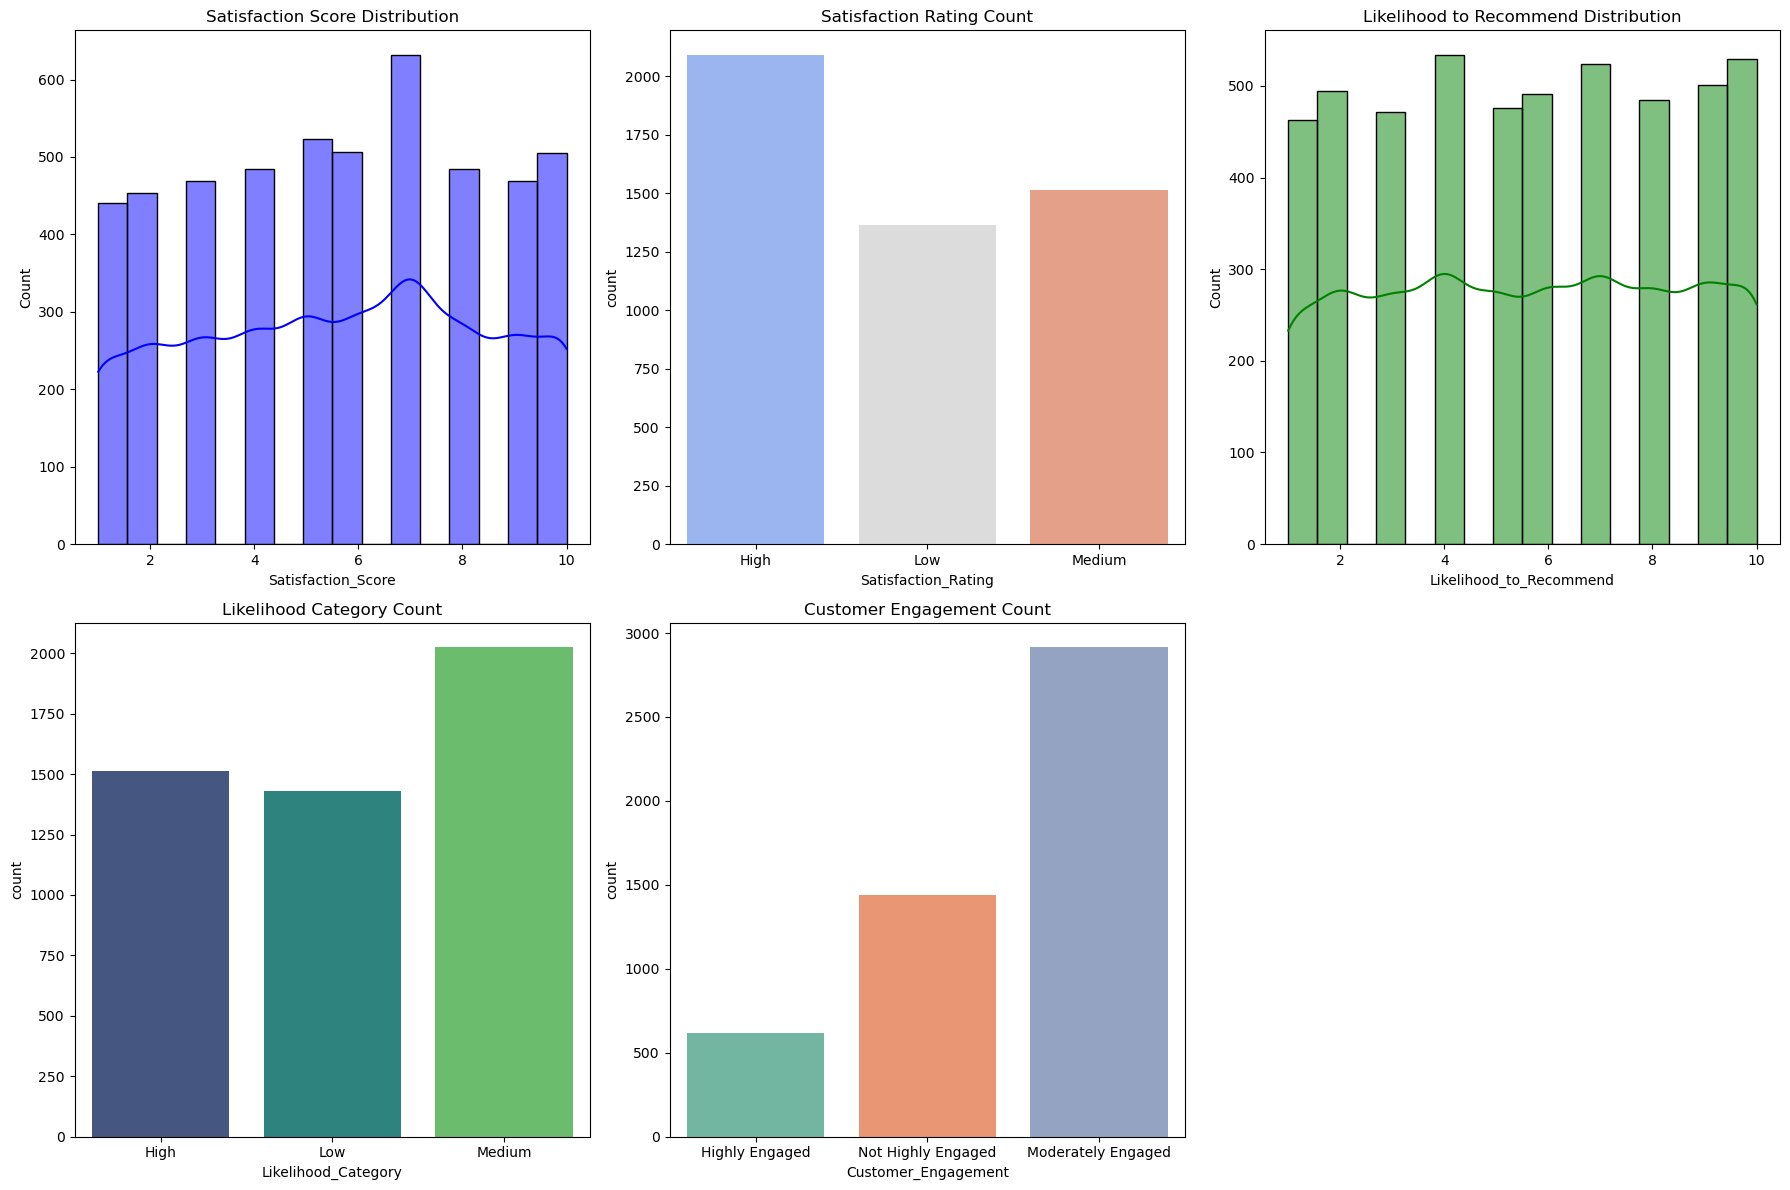

In [26]:
# Set up the figure for multiple subplots
plt.figure(figsize=(18, 12))

# 1. Satisfaction Score Distribution
plt.subplot(2, 3, 1)
sns.histplot(customers['Satisfaction_Score'], kde=True, color='blue')
plt.title('Satisfaction Score Distribution')

# 2. Satisfaction Rating Count (Fixed Warning)
plt.subplot(2, 3, 2)
sns.countplot(x='Satisfaction_Rating', data=customers, hue='Satisfaction_Rating', palette='coolwarm', legend=False)
plt.title('Satisfaction Rating Count')

# 3. Likelihood to Recommend Distribution
plt.subplot(2, 3, 3)
sns.histplot(customers['Likelihood_to_Recommend'], kde=True, color='green')
plt.title('Likelihood to Recommend Distribution')

# 4. Likelihood Category Count (Fixed Warning)
plt.subplot(2, 3, 4)
sns.countplot(x='Likelihood_Category', data=customers, hue='Likelihood_Category', palette='viridis', legend=False)
plt.title('Likelihood Category Count')

# 5. Customer Engagement Count (Fixed Warning)
plt.subplot(2, 3, 5)
sns.countplot(x='Customer_Engagement', data=customers, hue='Customer_Engagement', palette='Set2', legend=False)
plt.title('Customer Engagement Count')

# Adjust layout to avoid overlap
plt.tight_layout()

# Show the plot
plt.show()

In [27]:
#Finding the correlation coeffecient for 'Satisfaction_Score' and 'Likelihood_to_Recommend'

correlation_matrix = customers[['Satisfaction_Score', 'Likelihood_to_Recommend']].corr()
print(correlation_matrix)

#corr (Satisfaction_Score, Likelihood_to_Recommend) == (Likelihood_to_Recommend, Satisfaction_Score)

                         Satisfaction_Score  Likelihood_to_Recommend
Satisfaction_Score                 1.000000                -0.022439
Likelihood_to_Recommend           -0.022439                 1.000000


### 1. Satisfaction Score Distribution (Top-Left):

- Description: This bar chart displays the distribution of satisfaction scores among the customers.
- Key Insights: Scores are relatively balanced, with no significant skew. The overlaid line (likely a KDE curve) indicates the density, showing where most scores cluster.
- Implication: Customer satisfaction appears spread across all score ranges, suggesting varied customer experiences.
  
### 2. Satisfaction Rating Count (Top-Middle):

- Description: A bar chart showing the count of customers grouped by satisfaction rating (High, Medium, Low).
- Key Insights: "High" ratings dominate, followed by "Medium" and then "Low."
- Implication: The company is performing well overall in terms of customer satisfaction.
  
### 3. Likelihood to Recommend Distribution (Top-Right):

- Description: Bar chart showing the distribution of customers’ likelihood to recommend (scale 1-10).
- Key Insights: Scores are fairly uniform, with some peaks around higher values.
- Implication: A significant portion of customers are likely to recommend the service, though variability exists.
  
### 4. Likelihood Category Count (Bottom-Left):

- Description: A bar chart categorizing likelihood to recommend into High, Medium, and Low categories.
- Key Insights: "Medium" dominates, with "Low" and "High" nearly equal.
- Implication: There's room for improvement in shifting "Medium" to "High."

### 5. Customer Engagement Count (Bottom-Middle):

- Description: Engagement levels are divided into "Highly Engaged," "Moderately Engaged," and "Not Highly Engaged."
- Key Insights: The majority are "Moderately Engaged," with fewer "Highly Engaged."
- Implication: Efforts can be focused on increasing customer engagement levels.

### 6. Satisfaction Score vs. Likelihood to Recommend (Bottom-Right):

- Description: A scatter plot showing the relationship between satisfaction scores and likelihood to recommend.
- Key Insights: Points are spread out, indicating no strong correlation. The red line suggests a trend.
- Implication: While satisfaction influences recommendation, other factors may play a role.

## VISUALIZATION FOR PRODUCTS DATA

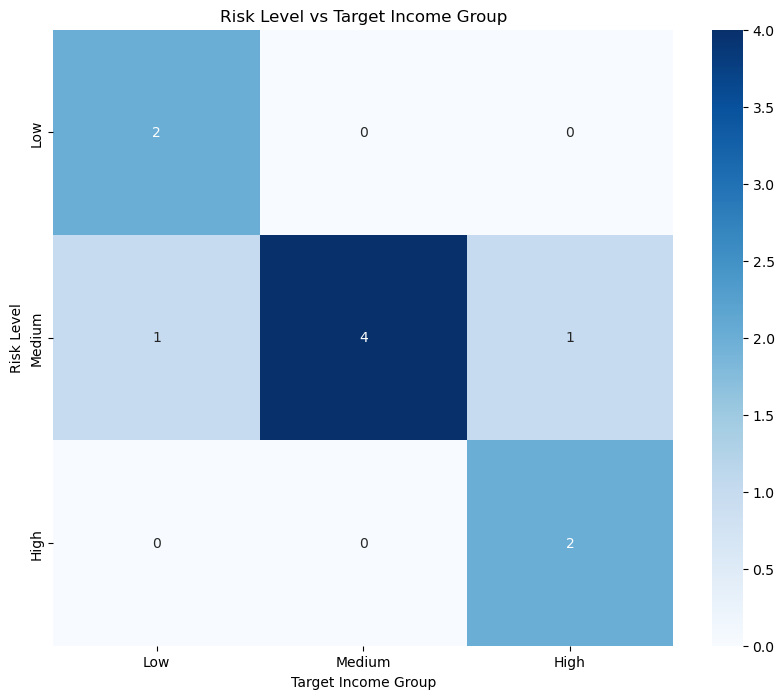

In [28]:
# Risk Level vs Target Income Group

# Define the desired order
risk_order = ['Low', 'Medium', 'High']
income_order = ['Low', 'Medium', 'High']

# Create the crosstab
cross_tab = pd.crosstab(products['Risk_Level'], products['Target_Income_Group'])

# Reorder the index and columns
cross_tab = cross_tab.reindex(index=risk_order, columns=income_order)

# Create the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cross_tab, annot=True, cmap='Blues', fmt='d')
plt.title('Risk Level vs Target Income Group')
plt.xlabel('Target Income Group')
plt.ylabel('Risk Level')
plt.show()

### Risk Level vs Target Income Group

The heatmap visualizes the relationship between Risk Level and Target Income Group across our financial products. Here's what we can interpret:

• Diagonal Pattern:
1. There's a clear diagonal pattern from top-left to bottom-right, suggesting a strong positive correlation between risk levels and target income groups
2. Products with low risk tend to target low-income groups
3. Products with medium risk predominantly target medium-income groups
4. High-risk products are mainly aimed at high-income groups


• Key Concentrations:

1. The highest concentration appears in the Medium Risk - Medium Income cell, indicating this is our most common product configuration
2. We see 2 products each in the Low Risk - Low Income and High Risk - High Income segments, showing a balanced approach at the extremes


• Notable Gaps:

1. There are no products in the High Risk - Low Income combination, which demonstrates responsible product design
2. Similarly, we don't see any Low Risk - High Income products, suggesting our high-income products are designed to offer higher potential returns with corresponding risk


• Business Implications:

1. The alignment between risk and income groups suggests a well-thought-out product strategy
2. The bank appears to practice responsible risk management by matching product risk levels with customers' income capacity
3. There's a clear focus on medium-risk, medium-income products, which likely represents the largest market segment

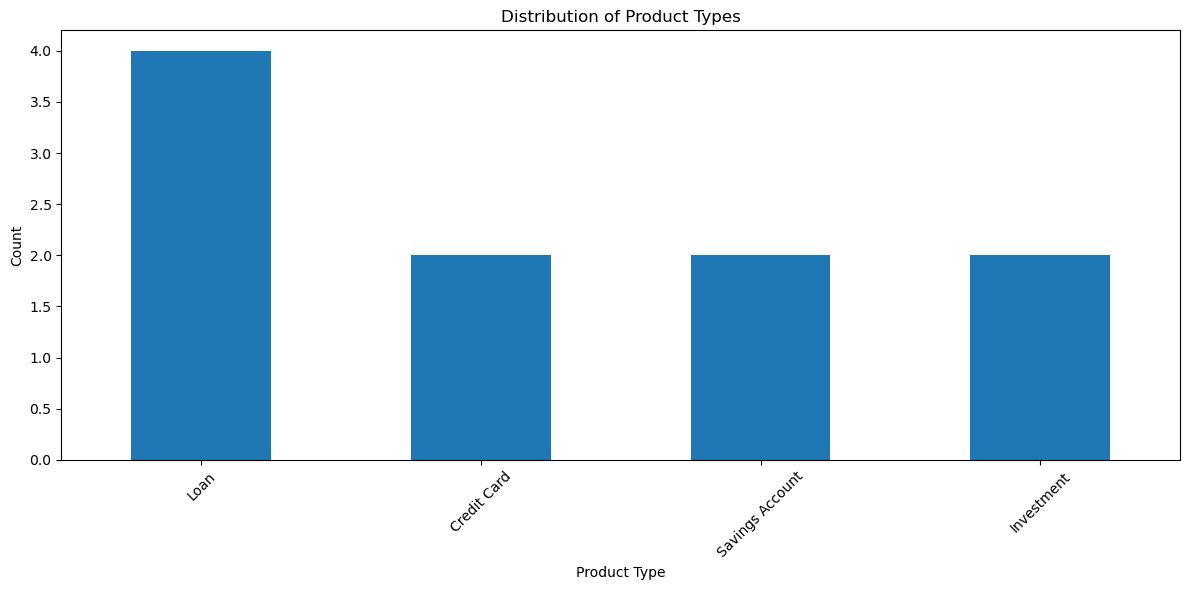

In [29]:
# Let's also visualize the distribution of Product Types
plt.figure(figsize=(12, 6))
products['Product_Type'].value_counts().plot(kind='bar')
plt.title('Distribution of Product Types')
plt.xlabel('Product Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Distribution of Product Types (Explanation)

- Loans (4 products):

1. The highest category with 4 different products
2. Includes Mortgage Loan, Auto Loan, Personal Loan, and Business Loan
3. Most of these have Medium risk level and varying target income groups


- Credit Cards (2 products):

1. Two offerings: Platinum Credit Card and Travel Credit Card
2. Both have Medium risk level and are targeted at Medium income groups
3. Each has distinct benefits (premium/exclusive benefits vs. travel rewards)


- Savings Accounts (2 products):

1. Gold Savings Account and Youth Savings Account
2. Both have Low risk level and are targeted at Low income groups
3. Different target audiences (general vs. young customers)


- Investment (2 products):

1. High-Yield Investment Account and Retirement Investment Fund
2. Both have High risk level and target High income groups
3. Different purposes (maximizing returns vs. retirement planning)

## VISUALIZATION FOR TRANSACTIONS DATA

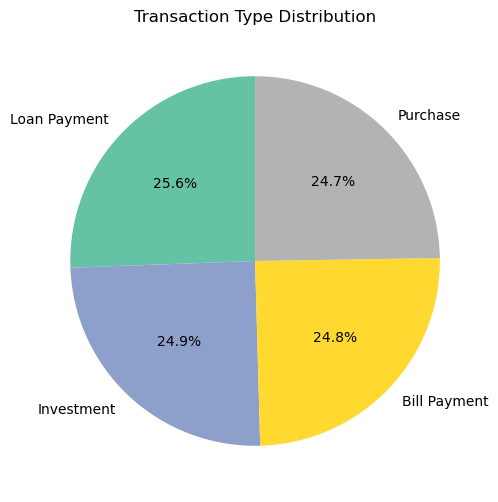

In [30]:
# Pie Chart for Transaction Type Distribution

plt.figure(figsize=(6, 6))
transactions['Transaction_Type'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, cmap="Set2")
plt.ylabel("")  # Remove y-label
plt.title("Transaction Type Distribution")
plt.show()

### Transaction Type Distribution
- Loan Payments: The top category indicates that users place a high priority on repaying their debt, which may be a sign of a responsible financial attitude or a strong borrowing culture. Financial institutions can benefit from this trend, which shows a consistent need for credit management services.
- Investments: A high proportion shows that users are becoming more financially aware and are actively making investments in assets that increase wealth. Financial institutions now have the chance to provide customized investment products.
- Purchases and Bill Payments: These two categories are almost equal, indicating consistent consumer expenditure on necessities as well as wants. Retailers and utility companies can more precisely predict demand thanks to this stability.

In [31]:
# Group by month and calculate statistics for the 'Month' column
monthly_sales_stats = transactions.groupby('Month')['Transaction_Amount'].describe()

# Sort months in calendar order (optional)
monthly_sales_stats = monthly_sales_stats.reindex([
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
])

# Display the statistics for each month
print(monthly_sales_stats)

           count         mean           std   min      25%      50%      75%  \
Month                                                                          
January    744.0  3135.504032  17574.087199  10.0  1271.75  2481.50  3662.75   
February   672.0  3035.272321  15021.278262  16.0  1263.25  2481.50  3578.25   
March      744.0  2955.174731   9775.199441  13.0  1249.25  2443.00  3682.00   
April      720.0  3232.765972  16316.270778  11.0  1292.25  2481.50  3719.50   
May        744.0  3749.199597  20440.386536  10.0  1265.75  2481.50  3832.25   
June       720.0  2457.652778   1413.335878  18.0  1242.50  2479.25  3598.50   
July       656.0  3034.336890  14134.943328  21.0  1271.50  2496.00  3679.50   
August       NaN          NaN           NaN   NaN      NaN      NaN      NaN   
September    NaN          NaN           NaN   NaN      NaN      NaN      NaN   
October      NaN          NaN           NaN   NaN      NaN      NaN      NaN   
November     NaN          NaN           

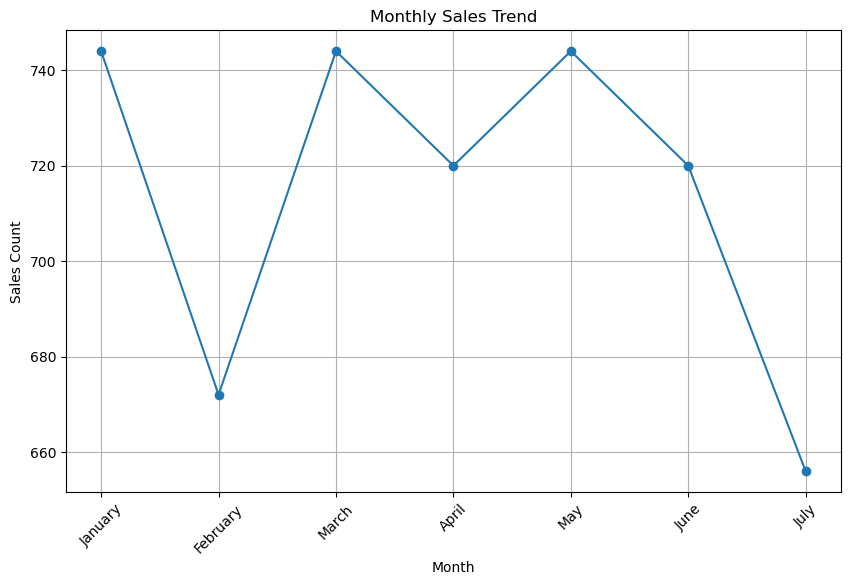

In [32]:
# Plot count of sales for each month
monthly_sales_stats['count'].plot(kind='line', figsize=(10, 6), marker='o', title='Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales Count')
plt.grid()
plt.xticks(rotation=45)
plt.show()

### Monthly Sales Trend
- Sales Volume Trends: Sales reach their highest levels in January and May, indicating increased financial activity. February and July see significant drops in transactions.
- Seasonal Patterns: A drop every February shows as a seasonal pattern likely due to post-holiday spending reductions after December and January. The drop from June to July might be a sign of a seasonal decline, brought on by mid-year holidays, a slowdown in business, or consumer hesitancy before larger purchases in later months.

In [33]:
# Group by month and calculate statistics for the 'Year' column
yearly_sales_stats = transactions.groupby('Year')['Transaction_Amount'].describe()

# Display the statistics for each month
print(yearly_sales_stats)

       count       mean           std   min     25%     50%     75%       max
Year                                                                         
2023  5000.0  3089.6398  14743.714207  10.0  1260.0  2481.5  3682.0  480300.0


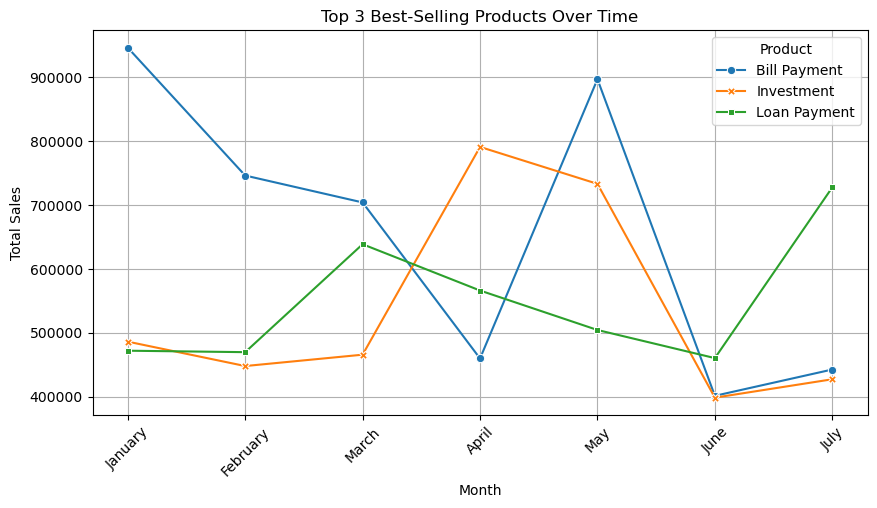

In [34]:
# Line graph visualization for top 3 products for each month

# Group by Month and Product, then sum sales
monthly_sales = transactions.groupby(['Month', 'Transaction_Type'])['Transaction_Amount'].sum().reset_index()

# Get the top 3 best-selling products overall
top_products = monthly_sales.groupby("Transaction_Type")["Transaction_Amount"].sum().nlargest(3).index

# Filter dataset to include only these top products
filtered_sales = monthly_sales[monthly_sales["Transaction_Type"].isin(top_products)]

# Pivot table to reshape data for line plotting
pivot_table = filtered_sales.pivot(index="Month", columns="Transaction_Type", values="Transaction_Amount")

# Sort months if needed (assuming months are strings like "January", "February", etc.)
month_order = ["January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"]
pivot_table = pivot_table.reindex(month_order)

# Plot the line graph
plt.figure(figsize=(10, 5))
sns.lineplot(data=pivot_table, markers=True, dashes=False)

# Titles and labels
plt.title("Top 3 Best-Selling Products Over Time")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.legend(title="Product")  # Add legend for product names
plt.grid(True)

plt.show()

### The Top 3 Products and their Sales Each Month

- Bill Payments show two major peaks in January and May, with notable drops between these months, reflecting when consumers typically handle their financial obligations.
- Investment Sales reach their highest point in April, possibly driven by tax season and financial planning activities, followed by a decline in subsequent months.
- Loan Payments begin at a low level and steadily rise until reaching their peak in July, indicating a preference for mid-year loan settlements.
These patterns help businesses anticipate customer behavior and plan their services accordingly throughout the year.

### 1. Customers Data (K-Means Clustering of Feedback_Comments)

## 13. DATA NORMALIZATION (STANDARDSCALER ON TRANSACTIONS & CUSTOMERS)
- Normalizing data using StandardScaler
- Standardization ensures all numerical features are on the same scale, improving the performance of clustering algorithms.

In [35]:
# Normalization using Standard Scaler
scaler = StandardScaler()
transactions[['Transaction_Amount']] = scaler.fit_transform(transactions[['Transaction_Amount']])
customers[['Satisfaction_Score']] = scaler.fit_transform(customers[['Satisfaction_Score']])

In [36]:
print("Normalized Transaction Amounts:")
print(transactions[['Transaction_Amount']].head())

print("Normalized Satisfaction Scores:")
print(customers[['Satisfaction_Score']].head())

Normalized Transaction Amounts:
   Transaction_Amount
0            0.025936
1           -0.041252
2           -0.208899
3           -0.204693
4           -0.087954
Normalized Satisfaction Scores:
   Satisfaction_Score
0            1.561246
1           -0.934036
2            1.561246
3            0.491840
4            0.848309


In [37]:
print("Data preprocessing and clustering completed successfully.")

Data preprocessing and clustering completed successfully.


# 15. Clustering 

In data mining, clustering is known as the technique of grouping similar data points together based on their features and characteristics. It can also be referred to as the process of creating clusters, or the grouping of a set of objects for objects in the same group to be more similar to each other than those in other groups.

## K-Means and Hierarchical Clustering

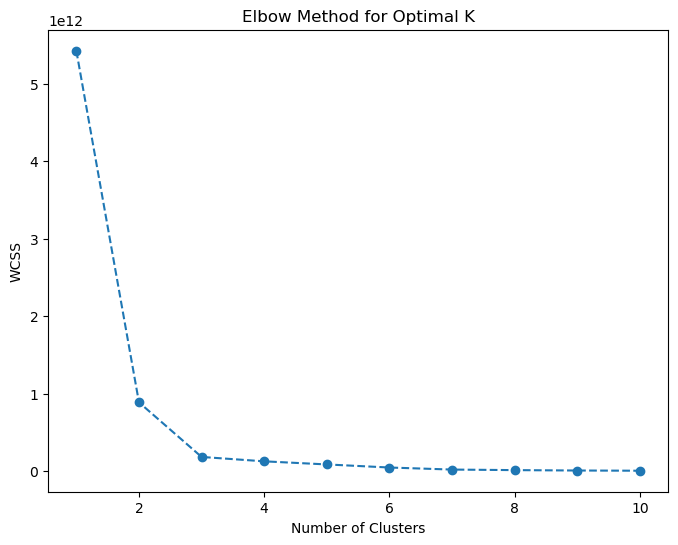

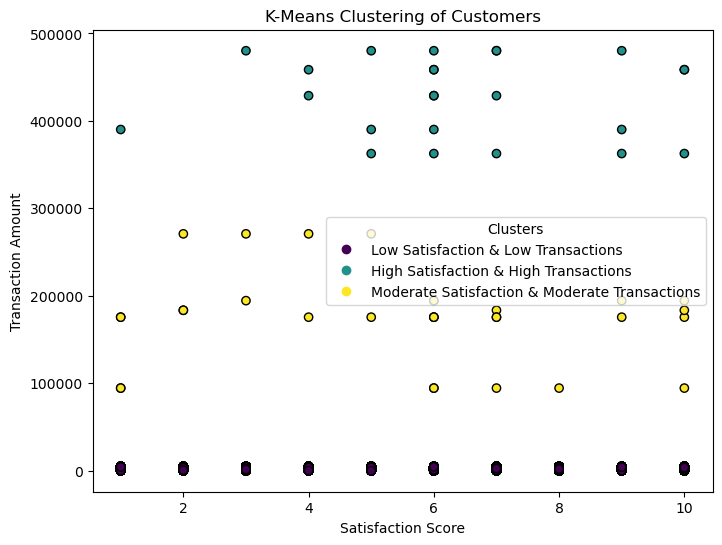

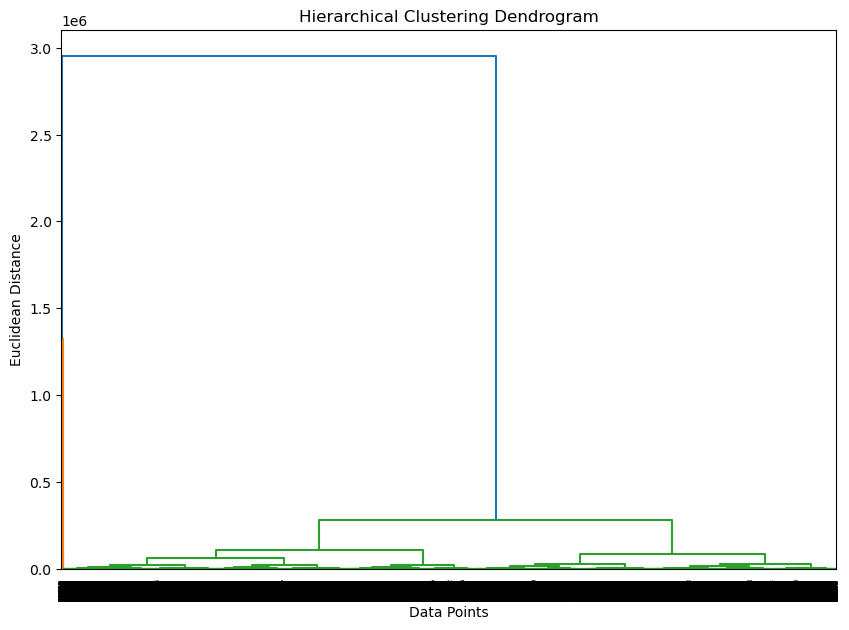

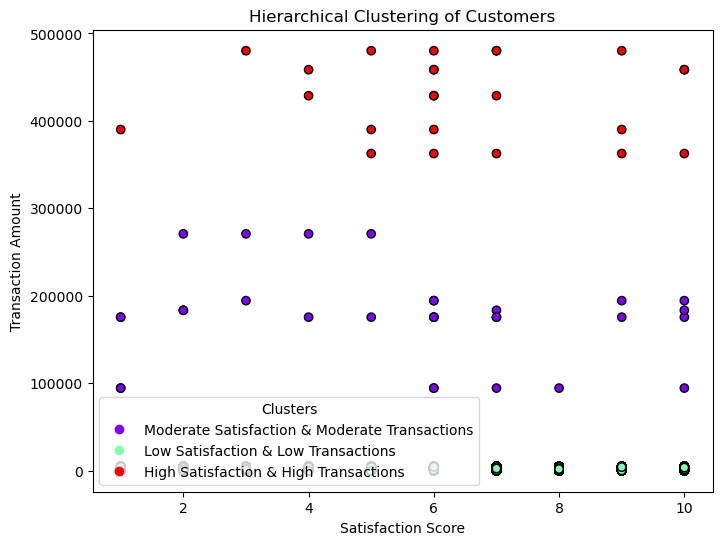

In [6]:
# Load datasets
df_feedback = pd.read_csv("Customer Feedback for Clustering.csv")
df_transactions = pd.read_csv("Transactions Data for Clustering.csv")

# Merge datasets on Customer_ID
df_merged = pd.merge(df_feedback, df_transactions, on="Customer_ID")

# Select relevant columns for clustering
X = df_merged[["Satisfaction_Score", "Transaction_Amount"]]

# Determine the optimal number of clusters using the Elbow Method
wcss = []
k_values = range(1, 11)
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Method
plt.figure(figsize=(8, 6))
plt.plot(k_values, wcss, marker='o', linestyle='--')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')  # Within-cluster sum of squares
plt.title('Elbow Method for Optimal K')
plt.show()

# Apply K-Means clustering (3 clusters)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X)
clusters = kmeans.labels_

df_merged["KMeans Cluster"] = clusters  # Add cluster labels to the dataset

cluster_mapping = {
    0: "Low Satisfaction & Low Transactions",  
    1: "High Satisfaction & High Transactions", 
    2: "Moderate Satisfaction & Moderate Transactions"  
}

df_merged["Cluster Label"] = df_merged["KMeans Cluster"].map(cluster_mapping)

# Plot the K-Means clusters
plt.figure(figsize=(8, 6))
scatter = plt.scatter(df_merged["Satisfaction_Score"], df_merged["Transaction_Amount"], 
                      c=clusters, cmap='viridis', edgecolors='black')
plt.xlabel("Satisfaction Score")
plt.ylabel("Transaction Amount")
plt.title("K-Means Clustering of Customers")

# Add custom cluster labels to the legend
handles, _ = scatter.legend_elements()
plt.legend(handles, cluster_mapping.values(), title="Clusters")
plt.show()

# Hierarchical Clustering
linked = linkage(X, method='ward')
plt.figure(figsize=(10, 7))
dendrogram(linked, labels=df_merged.index, orientation='top', distance_sort='descending', show_leaf_counts=True)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Euclidean Distance")
plt.show()

# Apply Agglomerative Clustering (3 clusters)
agg_cluster = AgglomerativeClustering(n_clusters=3, linkage='ward')
df_merged['Hierarchical Cluster'] = agg_cluster.fit_predict(X)

# Define custom cluster labels for Hierarchical Clustering
hierarchical_cluster_labels = {
    0: "Moderate Satisfaction & Moderate Transactions",
    1: "Low Satisfaction & Low Transactions",
    2: "High Satisfaction & High Transactions"
}

df_merged["Hierarchical Cluster Label"] = df_merged["Hierarchical Cluster"].map(hierarchical_cluster_labels)

# Plot Hierarchical Clusters
plt.figure(figsize=(8, 6))
scatter = plt.scatter(df_merged["Satisfaction_Score"], df_merged["Transaction_Amount"], 
                      c=df_merged["Hierarchical Cluster"], cmap='rainbow', edgecolors='black')

plt.xlabel("Satisfaction Score")
plt.ylabel("Transaction Amount")
plt.title("Hierarchical Clustering of Customers")

# Add custom cluster labels to the legend
handles, _ = scatter.legend_elements()
plt.legend(handles, hierarchical_cluster_labels.values(), title="Clusters", loc="lower left")

plt.show()

### Customer Segmentation Using K-Means and Hierarchical Clustering

In this analysis, we performed customer segmentation using both K-Means Clustering and Hierarchical Clustering based on Satisfaction Score and Transaction Amount. These clustering techniques helped us identify distinct customer groups, providing insights into their purchasing behavior.

1. Determining the Optimal Number of Clusters (Elbow Method)

Before applying K-Means, we used the Elbow Method to determine the optimal number of clusters. This method involves calculating the Within-Cluster Sum of Squares (WCSS) for different values of k and plotting the results. The point where the WCSS curve starts flattening out (forming an "elbow") indicates the ideal number of clusters.

From our analysis, we identified that three clusters best represented the dataset.

2. Applying K-Means Clustering

Once the optimal number of clusters was determined, we implemented K-Means Clustering, which assigned customers into three distinct groups based on their Satisfaction Score and Transaction Amount.

After analyzing the results, we mapped the clusters as follows:

- Low Satisfaction & Low Transactions (Purple) – Customers with low satisfaction scores and low transaction amounts.
- Moderate Satisfaction & Moderate Transactions (Yellow) – Customers with moderate satisfaction scores and moderate transaction amounts.
- High Satisfaction & High Transactions (Teal) – High-value customers with both high satisfaction scores and high transaction amounts.

During the clustering process, we encountered an issue where the numerical labels assigned by K-Means did not match the expected customer groups. To resolve this, we manually mapped the clusters based on the data distribution to ensure proper categorization.

We then visualized the clusters using a scatter plot, where each customer was plotted based on their satisfaction score and transaction amount, with colors representing the assigned clusters.

3. Applying Hierarchical Clustering

To validate our segmentation and explore an alternative clustering approach, we also applied Hierarchical Clustering. This technique builds a hierarchy of clusters by either merging smaller clusters (agglomerative clustering) or dividing larger clusters (divisive clustering).

In our case, we used Agglomerative Hierarchical Clustering, which starts with each data point as its own cluster and iteratively merges the closest clusters until only a predefined number of clusters remain. We measured cluster similarity using the Ward linkage method, which minimizes variance within clusters.

To visualize the hierarchical clustering process, we generated a dendrogram, which illustrates how individual customers were merged into clusters at different levels. Based on this dendrogram, we confirmed that three clusters were an appropriate choice, aligning with the results from the K-Means algorithm.

4. Comparison and Insights

- K-Means Clustering is efficient for large datasets and produces clear, well-separated clusters. However, it requires specifying the number of clusters in advance.
- Hierarchical Clustering provides a detailed clustering structure and does not require predefining the number of clusters. The dendrogram allows us to explore different cluster groupings interactively.
- Both methods produced similar customer segments, reinforcing the reliability of our clustering results.